# ALUNOS:
### - Cézar Augusto Nascimento Dias
### - Maxwell Alexandre Souza

In [28]:
import numpy as np
from skimage import io, color, filters, draw, feature
import matplotlib.pyplot as plt
from skimage.morphology import disk, binary_opening, binary_closing
from skimage.transform import hough_circle_peaks, hough_circle

# ETAPA 1:

### Objetivo: Aquisição e Preparação dos Dados
* Carregamento da imagem do dataset.
* Verificação das dimensões e canais para confirmar o formato RGB.
* Conversão do espaço de cores de RGB para HSV.
* Validação da conversão através da análise dos tipos de dados e intervalos de valores.
* Visualização preliminar.

### Fazendo a leitura da imagem:

In [29]:
imagem_original = io.imread('Imagem_1.jpg')

### Certificando que a imagem foi carregada:

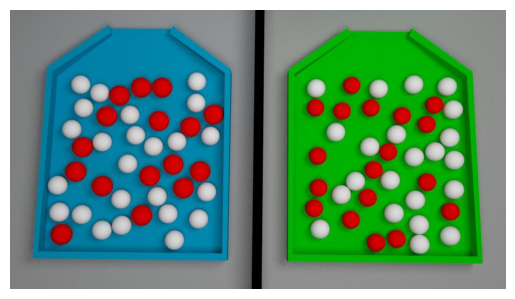

In [30]:
plt.imshow(imagem_original)
plt.axis('off')
plt.show()

### Verificando quantos canais de cores a imagem possui:

In [31]:
print('Forma da imagem original: ', imagem_original.shape)

Forma da imagem original:  (540, 960, 3)


"A imagem possui 3 canais de cores, logo é uma imagem em cores RGB. Como foi abordado em sala de aula, RGB não é a melhor representação quando se trata da manipulação da informação sensorial, pois os canais de cor (R, G, B) são altamente correlacionados com a intensidade luminosa. Isso significa que uma variação na iluminação (sombras ou brilhos) altera os valores dos três canais simultaneamente, dificultando a segmentação baseada apenas na cor.

Por outro lado, o espaço de cores HSV desacopla a informação de cor (Matiz/Hue) da informação de intensidade (Valor/Value). Dessa forma, podemos identificar objetos vermelhos ou brancos de maneira robusta, independentemente de estarem sob luz forte ou na sombra, analisando principalmente o canal H."

### Conversão para HSV e Validação de Dados

In [32]:
imagem_hsv = color.rgb2hsv(imagem_original)

### Verificando se a transformação de RGB para HSV foi executada:

In [33]:
print(f'RGB: Tipo de dados: {imagem_original.dtype} Valor mínimo: {imagem_original.min()} Valor máximo: {imagem_original.max()}')

RGB: Tipo de dados: uint8 Valor mínimo: 0 Valor máximo: 255


In [34]:
print(f'HSV: Tipo de dados: {imagem_hsv.dtype} Valor mínimo: {imagem_hsv.min()} Valor máximo: {imagem_hsv.max()}')

HSV: Tipo de dados: float64 Valor mínimo: 0.0 Valor máximo: 1.0


**Validação dos Dados:**
A conversão foi bem-sucedida e pode ser confirmada pela alteração no domínio numérico dos dados:
* **RGB:** Opera com números inteiros de 8 bits (`uint8`), variando de 0 a 255.
* **HSV:** A função `rgb2hsv` da biblioteca *scikit-image* normaliza automaticamente a matriz para ponto flutuante (`float64`), passando a trabalhar no intervalo de **0.0 a 1.0**. 

Compreender essa mudança de escala é essencial para definirmos corretamente os limiares de corte (*thresholds*) nas próximas etapas de segmentação.

### Exibindo a imagem em HSV:

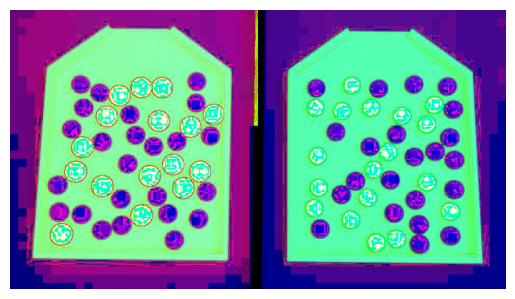

In [35]:
plt.imshow(imagem_hsv)
plt.axis('off')
plt.show()

# ETAPA 2:

### Objetivo: Segmentação por Limiarização (*Thresholding*)
* Aplicação da técnica de limiarização (*thresholding*) para isolar os objetos de interesse.
* Decomposição da imagem HSV nos seus três canais constituintes (H, S, V).
* Definição de intervalos lógicos (máscaras) para isolar a cor vermelha.
* Definição de intervalos lógicos (máscaras) para isolar a cor branca.

### Separação dos Canais e Lógica de Seleção:

In [9]:
H = imagem_hsv[:, :, 0] # Hue (Matiz)
S = imagem_hsv[:, :, 1] # Saturation (Saturação)
V = imagem_hsv[:, :, 2] # Value (Valor/Brilho)

### Estratégia de Segmentação:
* **Vermelho:** O canal Matiz (H) possui uma natureza cíclica. No modelo HSV normalizado (0.0 a 1.0), a cor vermelha encontra-se nas duas extremidades do espectro: no início (valores próximos de 0.0) e no fim (valores próximos de 1.0). Portanto, há a necessidade de uma máscara composta. Definimos também uma saturação mínima para não confundir com tons de branco/cinza.
* **Branco:** O branco não é definido pelo Matiz (H), mas sim pela combinação de baixa Saturação (S) e alto Valor/Brilho (V). O canal H torna-se irrelevante para esta cor.

### Implementação das Máscaras Binárias

#### MÁSCARA VERMELHA:
- O vermelho está no início (0.0 a 0.1) OU no fim (0.9 a 1.0) do espectro H.
- Definimos uma saturação mínima para não confundir com branco/cinza.

In [10]:
mascara_vermelho1 = (H >= 0.0) & (H <= 0.1) & (S > 0.4) & (V > 0.2)
mascara_vermelho2 = (H >= 0.9) & (H <= 1.0) & (S > 0.4) & (V > 0.2)
mascara_vermelho = mascara_vermelho1 | mascara_vermelho2

#### MÁSCARA BRANCA:
- O branco é definido por Saturação baixa (quase cinza) e Valor alto (brilhante).
- O Matiz (H) é irrelevante para o branco.

In [11]:
mascara_branco = (S < 0.2) & (V > 0.6)

### Visualização dos Resultados (Imagens Binárias)

**Por que a imagem tornou-se binária?**
Ao aplicar operadores relacionais (como maior que `>`, menor que `<`) sobre os canais da imagem, realizamos uma operação matemática de Limiarização (*Thresholding*). 

O resultado dessa operação não é mais uma intensidade luminosa ou cromática, mas sim um **mapa lógico** (*Boolean Map*):
* Os pixels que satisfazem a condição lógica (ex: `S > 0.4`) recebem o valor **`True` (ou 1)** e são visualizados como **Branco**.
* Os pixels que não satisfazem a condição recebem o valor **`False` (ou 0)** e são visualizados como **Preto**.

Essa binarização é fundamental para isolar a morfologia do objeto, descartando informações de textura e cor que não são necessárias para a contagem geométrica.

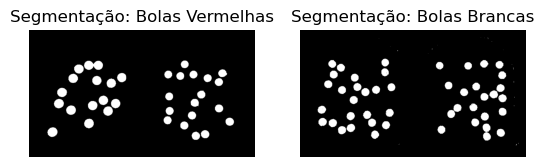

In [12]:
fig, axes = plt.subplots(1, 2)
ax = axes.ravel()

ax[0].imshow(mascara_vermelho, cmap='gray')
ax[0].set_title("Segmentação: Bolas Vermelhas")

ax[1].imshow(mascara_branco, cmap='gray')
ax[1].set_title("Segmentação: Bolas Brancas")

for a in ax:
    a.axis('off')

plt.show()

# ETAPA 3

### Objetivo: Tratamento Morfológico
Após a etapa de segmentação, observamos características distintas nas máscaras geradas:
1. **Máscara Vermelha:** Apresenta pouquíssimo ruído de fundo, mas os objetos (bolas) estão fisicamente muito próximos uns dos outros. O uso excessivo de operações como dilatação ou fechamento (*closing*) pode fundir os objetos adjacentes, prejudicando severamente a contagem.
2. **Máscara Branca:** Apresenta ruído ("sujeira") disperso pelo fundo da imagem, necessitando de uma limpeza mais rigorosa para não gerar falsos positivos.

Portanto, aplicaremos estratégias morfológicas distintas focadas na necessidade de cada canal: **preservação de separação** para o vermelho e **remoção de ruído** para o branco.


*Nota conceitual: A operação de Abertura (Opening) consiste em uma Erosão seguida de uma Dilatação. Ela é ideal para remover pequenos ruídos pontuais sem alterar significativamente a área e a forma dos objetos principais.*

### Definição do Elemento Estruturante
Utilizaremos um disco pequeno (raio 2) para realizar uma limpeza fina, garantindo que objetos próximos não sejam conectados acidentalmente.

In [13]:
elemento_estruturante = disk(2)

In [14]:
print(f'Elemento Estruturante (Raio 2):\n{elemento_estruturante}')

Elemento Estruturante (Raio 2):
[[0 0 1 0 0]
 [0 1 1 1 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 0]]


### Aplicação das Operações

* **Estratégia Vermelha (Foco: Separação):** Não aplicaremos fechamento para evitar a fusão de bolas adjacentes. Aplicaremos apenas uma leve abertura para garantir a remoção de micro-ruídos e suavizar as bordas, mantendo a individualidade das esferas.
* **Estratégia Branca (Foco: Limpeza):** Aplicaremos a abertura com o disco de raio 2, que se mostrou extremamente eficaz nos testes empíricos para remover os ruídos de fundo sem destruir a integridade geométrica das bolas maiores.

In [15]:
mascara_vermelho_final = binary_opening(mascara_vermelho, footprint=elemento_estruturante)

In [16]:
mascara_branco_final = binary_opening(mascara_branco, footprint=elemento_estruturante)

### Validação Visual
Nesta etapa, verificamos visualmente se o objetivo morfológico foi atingido: o canal vermelho não deve apresentar esferas "grudadas" (fundidas) e o canal branco deve apresentar um fundo limpo, livre de artefatos.

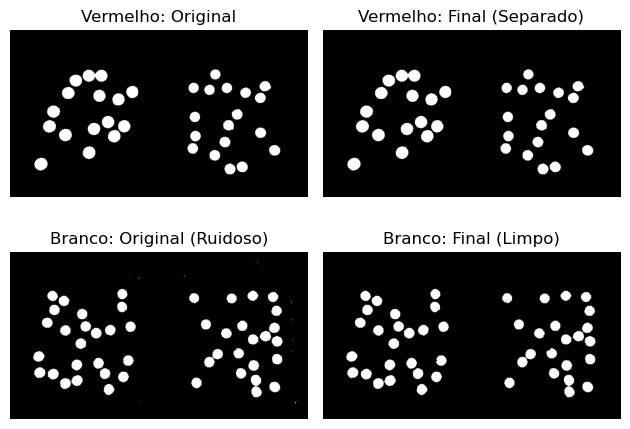

In [36]:
fig, axes = plt.subplots(2, 2)
ax = axes.ravel()

# Comparativo Vermelho
ax[0].imshow(mascara_vermelho, cmap='gray')
ax[0].set_title("Vermelho: Original")
ax[1].imshow(mascara_vermelho_final, cmap='gray')
ax[1].set_title("Vermelho: Final (Separado)")

# Comparativo Branco
ax[2].imshow(mascara_branco, cmap='gray')
ax[2].set_title("Branco: Original (Ruidoso)")
ax[3].imshow(mascara_branco_final, cmap='gray')
ax[3].set_title("Branco: Final (Limpo)")

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()

# ETAPA 4

### Objetivo: Extração de Bordas 
A Transformada de Hough Circular (CHT) opera sobre a informação de gradientes (bordas) da imagem. Como nossas máscaras atuais são formas binárias preenchidas (sólidas), precisamos extrair apenas os contornos dessas formas geométricas.

Optamos pelo detector de bordas **Canny** (`skimage.feature.canny`) em detrimento de filtros de gradiente simples (como Sobel) pelas seguintes razões teóricas:
1. **Saída Binária:** O algoritmo de Canny retorna diretamente uma máscara booleana, eliminando a necessidade de uma nova limiarização posterior.
2. **Adelgaçamento (*Thinning*):** O algoritmo possui uma etapa de supressão de não-máximos que garante contornos finos com apenas **1 pixel de largura**. Isso aumenta drasticamente a precisão geométrica na detecção do centro do círculo e reduz o custo computacional da etapa da Transformada de Hough.

### Aplicação do Filtro Canny

* O Canny é aplicado diretamente sobre as máscaras morfológicas finais.
* O parâmetro sigma controla o desvio padrão do filtro Gaussiano interno. 
* Utilizamos sigma=0.5 (um valor bem baixo) de forma intencional: valores maiores acabavam "derretendo" e apagando as bolas de gude muito pequenas.

In [18]:
edges_vermelho = feature.canny(mascara_vermelho_final, sigma=0.5)
edges_branco = feature.canny(mascara_branco_final, sigma=0.5)

### Visualização dos Contornos
Nesta etapa, verificamos se as formas sólidas foram convertidas corretamente em contornos finos. Estas imagens binárias de bordas puras são exatamente o *input* (entrada) que será entregue à função da Transformada de Hough Circular.

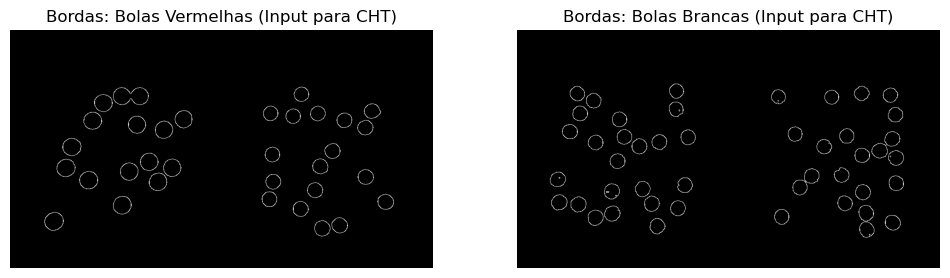

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ax = axes.ravel()

# Exibindo Bordas Vermelhas
ax[0].imshow(edges_vermelho, cmap='gray')
ax[0].set_title("Bordas: Bolas Vermelhas (Input para CHT)")
ax[0].axis('off')

# Exibindo Bordas Brancas
ax[1].imshow(edges_branco, cmap='gray')
ax[1].set_title("Bordas: Bolas Brancas (Input para CHT)")
ax[1].axis('off')

plt.show()

# ETAPA 5

### Objetivo: Transformada de Hough Circular e Detecção
A Transformada de Hough Circular (CHT) opera em um espaço de parâmetros 3D ($x, y, r$). Para otimizar a busca computacional e evitar falsos positivos, devemos restringir o intervalo de raios ($r$) esperados.

### Definição do Intervalo de Busca
Como o diâmetro das bolas de gude varia significativamente entre as imagens do conjunto de dados, não podemos utilizar um raio fixo. A solução é definir um intervalo de busca dinâmico (`np.arange`) que englobe tanto as menores esferas quanto as maiores observadas visualmente. A CHT testará cada raio dentro desse intervalo para encontrar o melhor ajuste geométrico para cada objeto na cena.

**Estratégia de Varredura:**
Definimos um intervalo amplo que vai de **5 pixels** (para capturar as bolas mais distantes/menores) até **80 pixels** (para as maiores). O passo (*step*) padrão de 1 pixel garante máxima precisão geométrica.

In [20]:
intervalo_raios = np.arange(5, 80)

In [21]:
print(f'Raios que serão testados: {intervalo_raios}')

Raios que serão testados: [ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28
 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52
 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76
 77 78 79]


### Execução da CHT (Acumulador)
* A função hough_circle gera um cubo de dados 3D. Para cada pixel de borda da imagem, ela "vota" em possíveis centros para todos os raios da lista acima.

In [22]:
hough_res_vermelho = hough_circle(edges_vermelho, intervalo_raios)

In [23]:
hough_res_branco = hough_circle(edges_branco, intervalo_raios)

### Filtragem dos Picos (Identificação dos Centros)

Precisamos processar a matriz de votos gerada pela CHT para garantir que não detectaremos círculos falsos ou sobrepostos. Para isso, utilizamos a função `hough_circle_peaks`, que analisa o espaço de acumuladores e retorna os parâmetros geométricos dos círculos mais proeminentes. 

As variáveis retornadas representam:
* **Acumulador (`acumulador`):** Valor de pico no espaço de Hough, representando a "força" ou quantidade de votos que aquele centro recebeu. Indica o grau de certeza da detecção.
* **Coordenadas do Centro (`cx`, `cy`):** Posições espaciais ($x, y$) do centroide da circunferência detectada.
* **Raios (`raios`):** O valor do raio ($r$) que maximizou a resposta do acumulador para aquele centro específico. Isso permite detectar múltiplas esferas de tamanhos distintos simultaneamente.

**Parametrização Otimizada:**
* **`min_xdistance` / `min_ydistance` (20px):** Implementa uma supressão não-máxima local para evitar múltiplas detecções concêntricas do mesmo objeto. O valor 20 permite a detecção de bolas encostadas, mas impede que a mesma bola receba dois círculos.
* **`threshold` (Dinâmico - 50%):** Definido como 0.5 do pico máximo global da respectiva máscara. Esta abordagem relativa confere robustez ao algoritmo contra variações de contraste e qualidade de borda entre diferentes imagens do dataset.
* **`total_num_peaks`:** Limite superior de segurança (150 para vermelhas, 100 para brancas), garantindo que todas as potenciais esferas sejam consideradas antes da filtragem final pelo threshold.

#### Vermelho:

In [24]:
# --- DETECÇÃO: MÁSCARA VERMELHA ---
acumulador_v, cx_v, cy_v, raios_v = hough_circle_peaks(hough_res_vermelho, intervalo_raios, 
                                                       total_num_peaks=150, 
                                                       min_xdistance=20, 
                                                       min_ydistance=20, 
                                                       threshold=0.5 * hough_res_vermelho.max())

#### Branco:

In [25]:

acumulador_b, cx_b, cy_b, raios_b = hough_circle_peaks(hough_res_branco, intervalo_raios, 
                                                       total_num_peaks=100, 
                                                       min_xdistance=20, 
                                                       min_ydistance=20, 
                                                       threshold=0.5 * hough_res_branco.max())

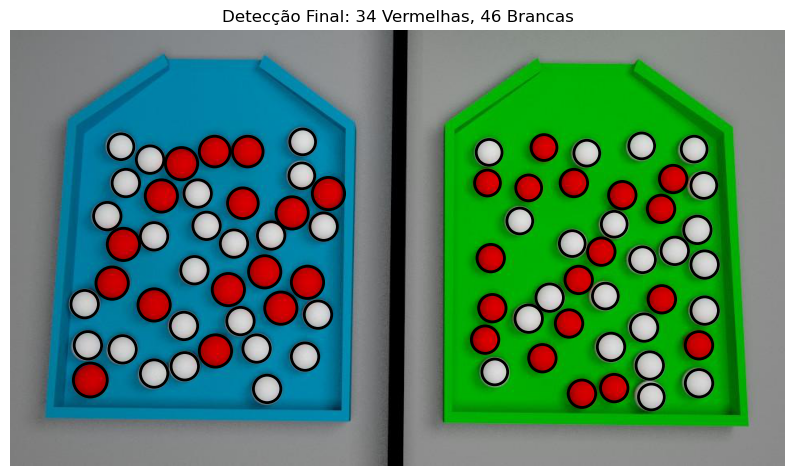

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(imagem_original)

for center_y, center_x, radius in zip(cy_v, cx_v, raios_v):
    c = plt.Circle((center_x, center_y), radius, color='black', fill=False, linewidth=2)
    ax.add_patch(c)


for center_y, center_x, radius in zip(cy_b, cx_b, raios_b):
    c = plt.Circle((center_x, center_y), radius, color='black', fill=False, linewidth=2)
    ax.add_patch(c)

ax.set_title(f"Detecção Final: {len(raios_v)} Vermelhas, {len(raios_b)} Brancas")
plt.axis('off')
plt.show()

# FUNÇÃO PARA TESTAR COM TODAS IMAGENS DO DATASET USADO

- Só mudar a célula de markdown para code para testar

imagens = ['Imagem_1.jpg', 'Imagem_2.jpg', 'Imagem_3.jpg', 'Imagem_4.jpg', 'Imagem_5.jpg',
           'Imagem_6.jpg', 'Imagem_7.jpg', 'Imagem_8.jpg', 'Imagem_9.jpg', 'Imagem_10.jpg',
           'Imagem_11.jpg', 'Imagem_12.jpg', 'Imagem_13.jpg', 'Imagem_14.jpg', 'Imagem_15.jpg',
           'Imagem_16.jpg', 'Imagem_17.jpg', 'Imagem_18.jpg', 'Imagem_19.jpg', 'Imagem_20.jpg',
           'Imagem_21.jpg', 'Imagem_22.jpg', 'Imagem_23.jpg', 'Imagem_24.jpg', 'Imagem_25.jpg',
           'Imagem_26.jpg', 'Imagem_27.jpg']

def detectar(lista_imagens):

    for nome_imagem in lista_imagens:
        print(f"Processando: {nome_imagem}...")
        
        # Leitura e Pré-processamento
        try:
            imagem_original = io.imread(nome_imagem)
        except FileNotFoundError:
            print(f"Erro: Arquivo {nome_imagem} não encontrado. Pulando...")
            continue

        imagem_hsv = color.rgb2hsv(imagem_original)
        H = imagem_hsv[:, :, 0]
        S = imagem_hsv[:, :, 1]
        V = imagem_hsv[:, :, 2]

        # Máscaras
        mascara_vermelho1 = (H >= 0.0) & (H <= 0.1) & (S > 0.4) & (V > 0.2)
        mascara_vermelho2 = (H >= 0.9) & (H <= 1.0) & (S > 0.4) & (V > 0.2)
        mascara_vermelho = mascara_vermelho1 | mascara_vermelho2
        mascara_branco = (S < 0.2) & (V > 0.6)

        # Morfologia
        elemento_estruturante = disk(2)
        mascara_vermelho_final = binary_opening(mascara_vermelho, footprint=elemento_estruturante)
        mascara_branco_final = binary_opening(mascara_branco, footprint=elemento_estruturante)

        # Canny e Hough
        edges_vermelho = feature.canny(mascara_vermelho_final, sigma=0.5)
        edges_branco = feature.canny(mascara_branco_final, sigma=0.5)
        
        intervalo_raios = np.arange(5, 80)
        
        hough_res_vermelho = hough_circle(edges_vermelho, intervalo_raios)
        hough_res_branco = hough_circle(edges_branco, intervalo_raios)

        # --- DETECÇÃO VERMELHO ---
        acumulador_v, cx_v, cy_v, raios_v = hough_circle_peaks(hough_res_vermelho, intervalo_raios,
                                                         total_num_peaks=150,
                                                         min_xdistance=20,
                                                         min_ydistance=20,
                                                         threshold=0.5 * hough_res_vermelho.max())

        # --- DETECÇÃO BRANCO ---
        acumulador_b, cx_b, cy_b, raios_b = hough_circle_peaks(hough_res_branco, intervalo_raios,
                                                         total_num_peaks=100,
                                                         min_xdistance=20,
                                                         min_ydistance=20,
                                                         threshold=0.5 * hough_res_branco.max())

        
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.imshow(imagem_original)
   
        for center_y, center_x, radius in zip(cy_v, cx_v, raios_v):
            c = plt.Circle((center_x, center_y), radius, color='black', fill=False, linewidth=2)
            ax.add_patch(c)
   
        for center_y, center_x, radius in zip(cy_b, cx_b, raios_b):
            c = plt.Circle((center_x, center_y), radius, color='black', fill=False, linewidth=2)
            ax.add_patch(c)
   
       
        ax.set_title(f"Arquivo: {nome_imagem} | Detecção: {len(raios_v)} Vermelhas, {len(raios_b)} Brancas")
        plt.axis('off')
        plt.show()

detectar(imagens)
